# Project Lifecycle: Conversational Movie Recommendation System
**Notebook 1: EDA & Production Data Preparation**

## Problem Statement
The goal of this system is to handle free-form natural language queries (e.g., “mind-bending sci-fi like Inception”), retrieve relevant movies using semantic search, and rank them using a hybrid scoring mechanism.

This notebook prepares the foundation by:
1. Merging MovieLens (interactions) with TMDB (metadata).
2. Analyzing data distributions and sparsity to justify our architectural decisions.
3. Building a clean, noise-free text representation ("Metadata Soup") for Stage 1 Retrieval.

### Data source
tmdb - https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

movies, ratings, links - https://grouplens.org/datasets/movielens/20m/

### 1. Data Preparation

#### 1.1 Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### 1.2 Load Data

In [ ]:
# Load MovieLens
ratings = pd.read_csv("/content/ratings.csv")
movies = pd.read_csv("/content/movies.csv")
links = pd.read_csv("/content/links.csv")

# Load TMDB
tmdb = pd.read_csv("/content/tmdb_5000_movies.csv")

print(ratings.shape, movies.shape, tmdb.shape)

(20000263, 4) (27278, 3) (4803, 20)


#### 1.3 Basic Information

In [ ]:
print ("movies.csv Top 5 Records")
movies.head()

movies.csv Top 5 Records


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
print ("rating.csv Top 5 Records")
ratings.head()

rating.csv Top 5 Records


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [ ]:
print ("tmdb.csv Top 5 Records")
tmdb.head()

tmdb.csv Top 5 Records


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
print ("links.csv Top 5 Records")
links.head()

links.csv Top 5 Records


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


#### 1.4 Merge Data


* Using only the intersection reduced the dataset significantly, so I switched to a left join to preserve the full MovieLens catalog while enriching available items with TMDB metadata. This better reflects real-world systems where data is often partially available.

In [ ]:
# 2. Data Alignment & Merging
# Clean links to ensure proper mapping between MovieLens and TMDB
links['tmdbId'] = pd.to_numeric(links['tmdbId'], errors='coerce')
links = links.dropna(subset=['tmdbId'])
links['tmdbId'] = links['tmdbId'].astype(int)

# Map tmdbId to the movies dataframe
movies = movies.merge(links[['movieId', 'tmdbId']], on='movieId', how='left')

# Left join to preserve all MovieLens interactions, enriching with TMDB metadata where available
df = movies.merge(tmdb, left_on='tmdbId', right_on='id', how='left')

# Select and rename relevant features
features = ['movieId', 'title_x', 'genres_x', 'keywords', 'overview', 'popularity', 'vote_average', 'vote_count', 'release_date']
df = df[features].rename(columns={'title_x': 'title', 'genres_x': 'genres'})

# Extract release year
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

print(f"Dataset merged successfully. Total unique movies: {df['movieId'].nunique()}")

Dataset merged successfully. Total unique movies: 27278


#### Select Relevant Features
* I select only relevant features needed for recommendation: movieId (ID), title (display), genres (categorical info), overview (text for similarity), popularity/vote metrics (ranking signals), and release_date (recency).  
* Unnecessary columns (budget, revenue, etc.) are removed to reduce noise and complexity.  
* After merging, duplicate columns like title_x and genres_x are renamed for clarity.  
* This keeps the dataset clean, interpretable, and focused on retrieval + ranking tasks.  
* Overall, I retain only features that directly improve recommendation quality and explainability.

#### 1.5 Data Cleaning

In [ ]:
df['overview'] = df['overview'].fillna("")
df['vote_average'] = df['vote_average'].fillna(0)
df['vote_count'] = df['vote_count'].fillna(0)

df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['year'] = df['year'].fillna(2000)

### 2. Exploratory Data Analysis (EDA)
Before modeling, we must understand the shape of our data. This dictates our system architecture.



#### 2.1 Overview Coverage

In [ ]:
coverage = (df['overview'].str.len() > 0).mean()
print(f"Overview coverage: {coverage:.2%}")

Overview coverage: 15.50%


##### Key Insights

1. After merging the datasets, most movies were missing descriptions — only about 15% had overviews. This highlighted a major data gap.

2. Instead of dropping those movies, I generated fallback strategy (In step 3) using title and genres, which helped retain the full dataset.

3. After this fix, overview coverage improved to 100%, meaning every movie now has some textual representation.

#### 2.2 Ratings Sparsity and Long-Tail Distribution

Ratings Sparsity: 99.4600%


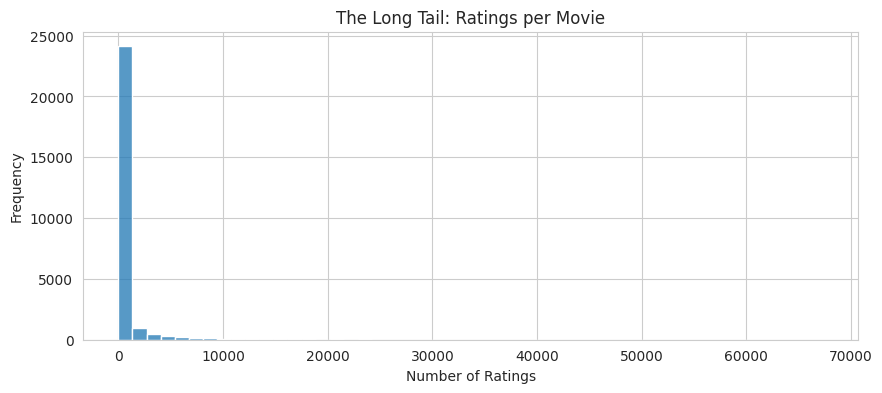

In [ ]:
# Sparsity & The "Cold Start" Problem
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

sparsity = 1 - (num_ratings / (num_users * num_movies))
print(f"Ratings Sparsity: {sparsity * 100:.4f}%")

# Plot Long-Tail Distribution
movie_counts = ratings.groupby('movieId').size()
plt.figure(figsize=(10, 4))
sns.histplot(movie_counts, bins=50)
plt.title("The Long Tail: Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Frequency")
plt.show()

**Architectural Decision:** With sparsity > 99% and a massive long-tail, a pure Collaborative Filtering model will fail for niche movies. This justifies our **Stage 1 Content-Based Retrieval (Sentence Transformers)** to bridge the gap using semantic metadata.

#### 2.3 Popularity Bias

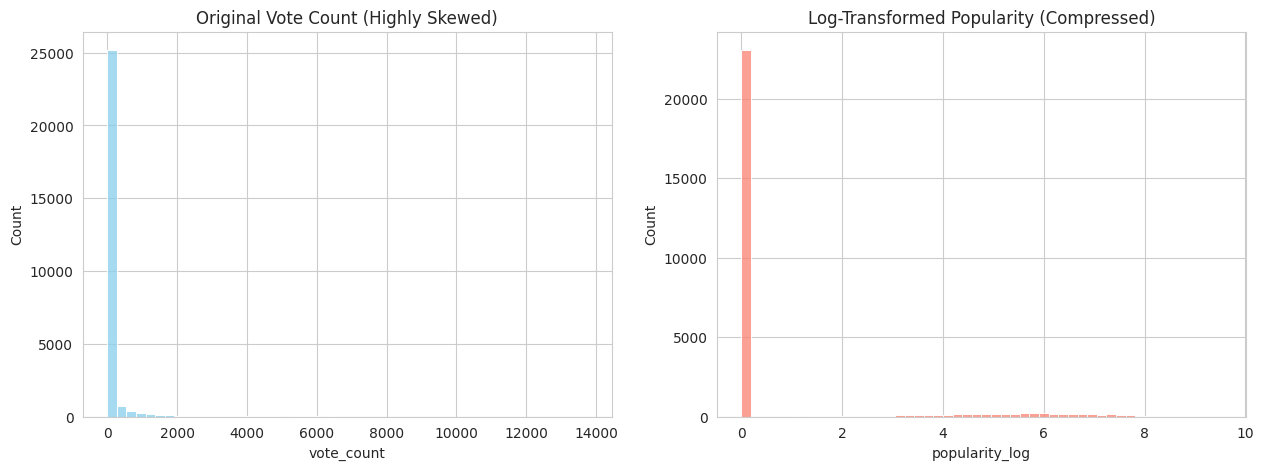

In [13]:
# 3. Handling Popularity Bias
# Why: Raw vote counts follow a power law. We need to compress this to make
# other features (like semantic similarity) competitive in our ranking stage.

df['vote_count'] = df['vote_count'].fillna(0)
df['popularity_log'] = np.log1p(df['vote_count'])

# Visualization: Before vs After
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['vote_count'], bins=50, ax=ax1, color='skyblue')
ax1.set_title("Original Vote Count (Highly Skewed)")

sns.histplot(df['popularity_log'], bins=50, ax=ax2, color='salmon')
ax2.set_title("Log-Transformed Popularity (Compressed)")

plt.show()

To reduce popularity bias, I applied log scaling to the vote count feature so that highly popular movies do not dominate the recommendations.

#### 2.4 Feature Correlation

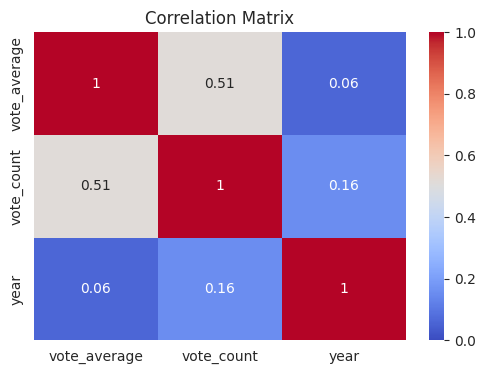

In [12]:
# Feature Correlation for Hybrid Ranking
df['vote_average'] = df['vote_average'].fillna(0)
df['vote_count'] = df['vote_count'].fillna(0)

corr_matrix = df[['vote_average','vote_count','year']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Correlation Matrix")
plt.show()

**Architectural Decision:** `vote_count` and `vote_average` have a moderate correlation (0.51), meaning they capture different signals (popularity vs. quality). We will use both as independent weights in our **Stage 2 Hybrid Ranker**.

#### 2.5 Genre Distribution

<Axes: title={'center': 'Genre Frequency'}>

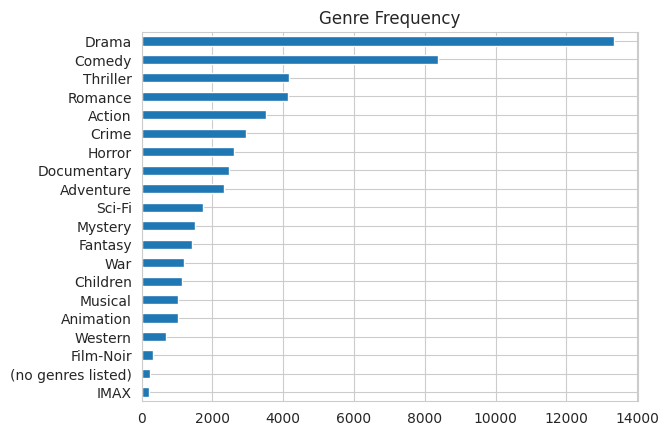

In [16]:
# Analyzing Genre distribution
from collections import Counter

genre_list = df['genres'].str.split('|').explode()
genre_counts = Counter(genre_list)

# Visualization
pd.Series(genre_counts).sort_values().plot(kind='barh', title='Genre Frequency')

* Genres: Drama and Comedy account for a massive chunk of the dataset, meaning your recommendation engine will be "smarter" about these categories by default. If a user asks for something niche like a "Western" or "Film-Noir," the candidate pool is significantly smaller, which increases the risk of recommending irrelevant popular movies just to fill the list.

* Since Drama is such a broad, high-frequency tag, it often acts as a "noisy" feature. In our Stage 2 ranking, we shouldn't give too much weight to a "Drama" match alone; instead, we need the SentenceTransformer to pick up on the specific sub-themes in the overview to distinguish a "Legal Drama" from a "Period Drama."

* We can see "IMAX" and "(no genres listed)" appearing as genres. In a production pipeline, these are noise markers, not thematic signals. We should filter these out before building our "metadata soup," as "IMAX" describes a screen format, not the movie's content, and could lead the embedding model to cluster unrelated movies together simply because they shared a technical format.

### 3. Data Hygiene & Metadata Soup Construction

#### 3.1 Clean Genres (Noise Reduction)

In [22]:
def clean_genres(genre_str):
    if pd.isna(genre_str) or genre_str == "(no genres listed)":
        return ""
    # Removing non-thematic technical noise like 'IMAX'and '(no genres listed)'
    noise = {'IMAX', '(no genres listed)'}
    genres = [g.strip() for g in str(genre_str).split('|') if g.strip() not in noise]
    return " ".join(genres)

df['cleaned_genres'] = df['genres'].apply(clean_genres)

<Axes: title={'center': 'Genre Frequency'}>

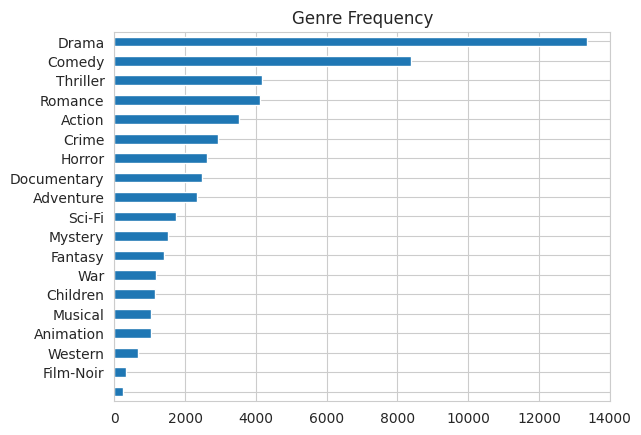

In [23]:
# checking
genre_list = df['cleaned_genres'].str.split(' ').explode()
genre_counts = Counter(genre_list)
pd.Series(genre_counts).sort_values().plot(kind='barh', title='Genre Frequency')

#### 3.2 Smart Fallback for Semantic Retrieval

In [24]:
# If overview is missing, we use Title + Genre to ensure the movie exists in vector space.
df['overview'] = df.apply(
    lambda x: f"{x['title']} {x['cleaned_genres']}" if not x['overview'] or x['overview'] == ""
    else x['overview'],
    axis=1
)

In [25]:
# checking the fix
coverage = (df['overview'].str.len() > 0).mean()
print(f"After fallback strategy Overview coverage: {coverage:.2%}")

After fallback strategy Overview coverage: 100.00%


#### 3.3 Deduplication
Since merging datasets can introduce duplicates, I sorted by popularity to ensure we keep the most data-rich 'canonical' version of each film while stripping away redundant entries.

In [27]:
df = df.sort_values(by='vote_count', ascending=False)
df = df.drop_duplicates(subset=['title', 'year'], keep='first')

#### 3.4 The Metadata Soup
Combining all textual signals into a single lower-case string for the Bi-Encoder.

In [38]:
import ast

def extract_json_names(json_str):
    """
    Parses a JSON string and extracts only the 'name' values.
    Example: '[{"name": "sci-fi"}]' -> 'sci-fi'
    """
    if not json_str or pd.isna(json_str) or json_str == "[]":
        return ""

    try:
        # Convert string representation of list to actual list
        data = ast.literal_eval(json_str)
        # Extract the 'name' from each dictionary
        return " ".join([i['name'] for i in data])
    except (ValueError, SyntaxError):
        # Fallback if the data is already cleaned or in a different format
        return str(json_str).replace('|', ' ')

# Update the soup function
def create_soup(row):
    # 1. Clean the keywords from JSON to a simple string
    kw_cleaned = extract_json_names(row['keywords'])

    # 2. Combine all features
    # Note: Using 'cleaned_genres' from our previous step
    components = [
        str(row['title']),
        str(row['cleaned_genres']),
        kw_cleaned,
        str(row['overview'])
    ]

    # Join with spaces and lowercase everything
    return " ".join(components).lower()

# Apply the change
df['soup'] = df.apply(create_soup, axis=1)

In [41]:
print("Sample cleaned soup:")
print(df['soup'].iloc[10])

Sample cleaned soup:
matrix, the (1999) action sci-fi thriller saving the world artificial intelligence man vs machine philosophy prophecy martial arts self sacrifice fight insurgence virtual reality dystopia truth cyberpunk woman director messiah gnosticism set in the 22nd century, the matrix tells the story of a computer hacker who joins a group of underground insurgents fighting the vast and powerful computers who now rule the earth.


#### 3.5 norm_popularity
I applied Min-Max scaling to the log-transformed popularity to ensure the feature stays within a 0-1 range. This prevents popularity from dominating the semantic similarity scores during the hybrid ranking stage, allowing for a more balanced recommendation.

In [45]:
df['norm_popularity'] = (df['popularity_log'] - df['popularity_log'].min()) / \
                        (df['popularity_log'].max() - df['popularity_log'].min())

# Updated final columns
final_cols = ['movieId', 'title', 'year', 'soup', 'norm_popularity', 'vote_average', 'vote_count']

"For the final dataset, I retained a lean set of high-signal features mapped directly to our two-stage architecture: the soup column serves as the primary textual representation for semantic retrieval, while norm_popularity and vote_average provide the standardized numerical weights required for high-precision hybrid ranking. By dropping redundant metadata and normalizing our popularity scores, we ensure the system remains memory-efficient and that no single feature unfairly dominates the final recommendation score."

In [46]:
# using Parquet to preserve the  soup column with long text and log-transformed numerical types exactly.
df[final_cols].to_parquet('movies_processed_final.parquet', index=False)